# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

### **1. Sumber Dataset**

Dataset untuk proyek *System Machine Learning* ini diperoleh dari repositori publik **Kaggle** yang dirilis secara resmi oleh IBM Data Scientists.

* **Nama Dataset**: IBM HR Analytics Employee Attrition & Performance
* **Tautan Sumber (URL)**: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
* **Konteks & Gambaran Data**: Data ini merupakan dataset simulasi yang mencakup 1.470 data karyawan dengan 35 kolom fitur (demografi, lingkungan kerja, performa, dan kompensasi). Dataset ini digunakan untuk memprediksi variabel target biner **`Attrition`** (*Yes* untuk karyawan yang keluar, atau *No* untuk karyawan yang bertahan di perusahaan).


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Install MLflow if not already installed
!pip install mlflow

# 1. Library Analisis Data & Manipulasi Struktur
import pandas as pd
import numpy as np

# 2. Library Visualisasi Data (Keperluan EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Library Preprocessing & Data Splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# 4. Library Model Machine Learning (Scikit-Learn)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 5. Library MLOps & Experiment Tracking (Sesuai Spesifikasi)
import mlflow
import mlflow.sklearn

# 6. Mengabaikan Peringatan yang Tidak Diperlukan
import warnings
warnings.filterwarnings('ignore')

# Menampilkan versi library utama untuk memastikan kesesuaian env
print(f"Pandas version: {pd.__version__}")
print(f"MLflow version: {mlflow.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.6/887.6 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# ==========================================
# 3. Memuat Dataset (Revisi - Google Drive)
# ==========================================

import os

# ID File Google Drive untuk dataset IBM Attrition
file_id = "18HKY-qHnBxDbxfZMYcEsV1AM0rNosOfL"
dataset_path = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

# Mengunduh file dari Google Drive jika belum ada di lokal runtime
if not os.path.exists(dataset_path):
    print("Sedang mengunduh dataset dari Google Drive...")
    # Menggunakan gdown (pustaka bawaan Colab) untuk mengunduh lewat file ID
    os.system(f"gdown --id {file_id} -O {dataset_path}")

try:
    # Memuat dataset ke dalam DataFrame pandas
    df = pd.read_csv(dataset_path)
    print("✓ Dataset berhasil dimuat!")
    print(f"Dimensi data: {df.shape[0]} baris dan {df.shape[1]} kolom\n")

    # Menampilkan 5 baris pertama data untuk inspeksi struktur awal
    print("--- 5 Baris Pertama Dataset ---")
    display(df.head())

    # Menampilkan informasi tipe data dan nilai kosong (missing values)
    print("\n--- Informasi Ringkas Dataset ---")
    df.info()

except Exception as e:
    print(f"⚠️ Gagal memuat dataset: {e}")
    print("Pastikan link file di Drive kamu sudah diatur ke 'Siapa saja yang memiliki link' (Public).")

Sedang mengunduh dataset dari Google Drive...
✓ Dataset berhasil dimuat!
Dimensi data: 1470 baris dan 35 kolom

--- 5 Baris Pertama Dataset ---


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2



--- Informasi Ringkas Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   i

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

=== 1. INFORMASI RINGKAS DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null  

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470,1470,1470.000000,1470,1470.000000,1470.000000,1470,1470.0,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
unique,NaN,2,3,NaN,3,NaN,NaN,6,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,No,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1233,1043,NaN,961,NaN,NaN,606,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,36.923810,NaN,NaN,802.485714,NaN,9.192517,2.912925,NaN,1.0,1024.865306,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,NaN,NaN,403.509100,NaN,8.106864,1.024165,NaN,0.0,602.024335,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,NaN,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,NaN,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,491.250000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,NaN,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,1020.500000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,NaN,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,1555.750000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000




=== 3. PENGECEKAN MISSING VALUES & DUPLIKAT ===
[Missing Values per Kolom]
Tidak ada missing values di kolom mana pun.

Jumlah total baris duplikat: 0


=== 4. DETEKSI FITUR KONSTAN ===
Fitur konstan/redundant yang terdeteksi: ['EmployeeCount', 'Over18', 'StandardHours']


=== 5. VISUALISASI DISTRIBUSI & HUBUNGAN VARIABEL (UNIVARIAT & BIVARIAT) ===


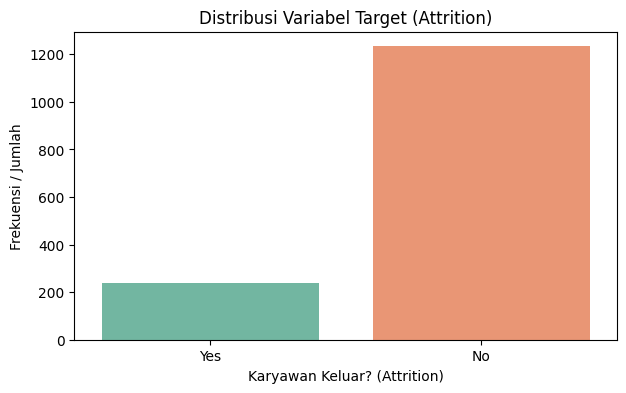

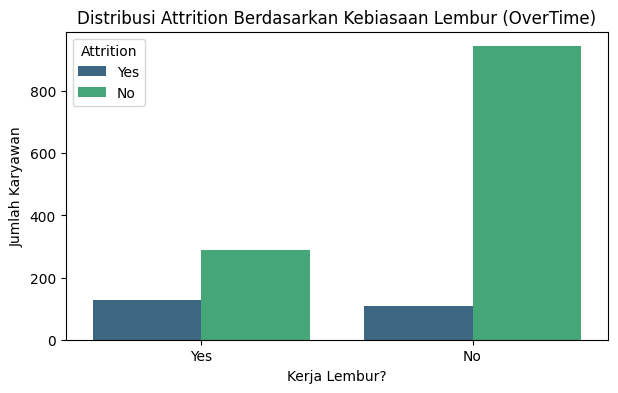

=== 6. DETEKSI OUTLIER (BOXPLOT) ===


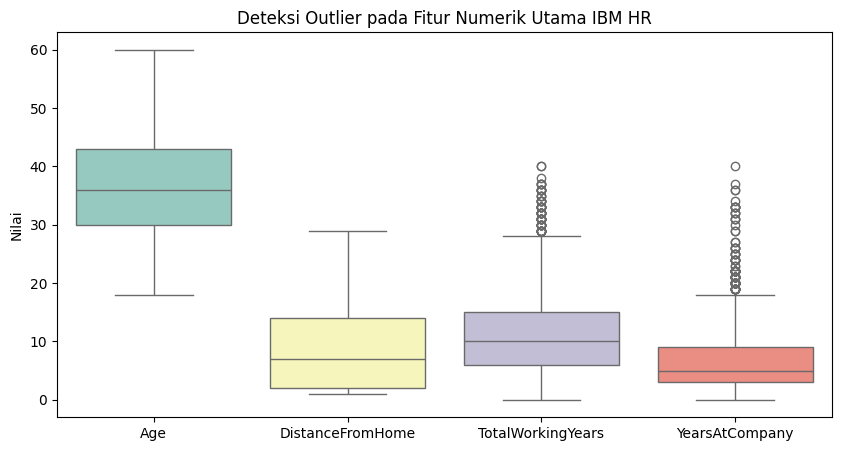

=== 7. ANALISIS KORELASI (HEATMAP) ===


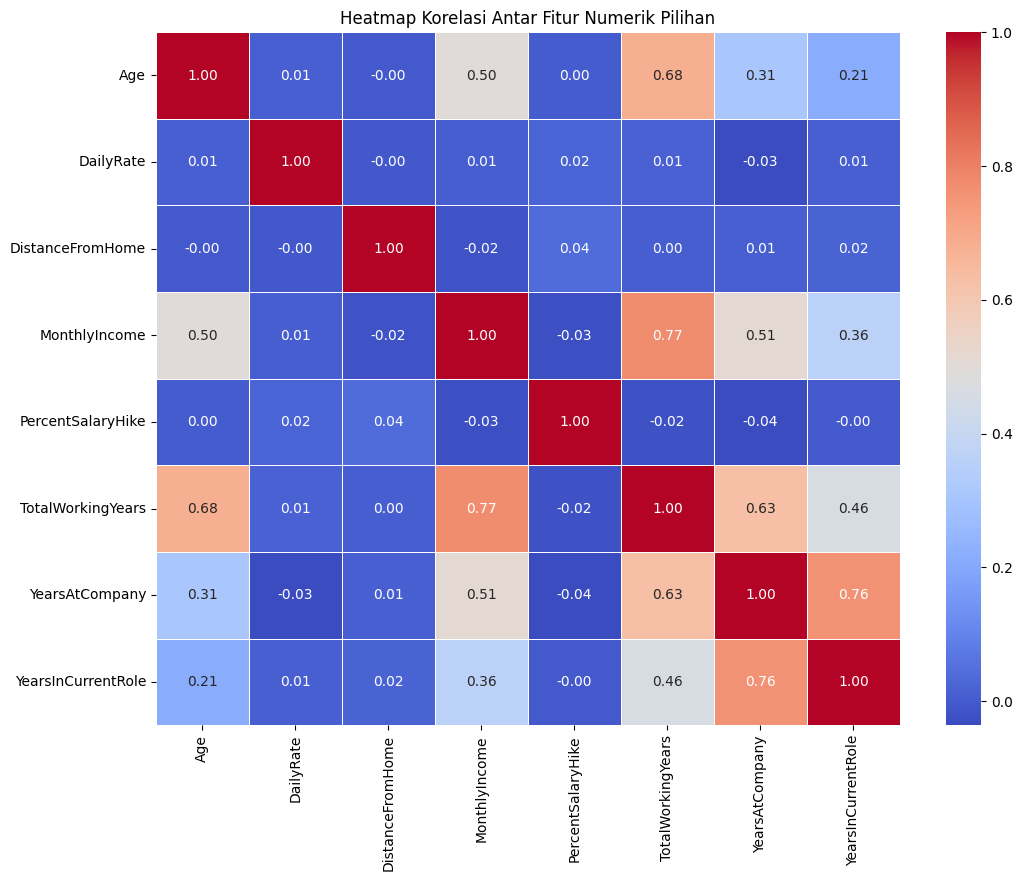

=== 8. DISTRIBUSI MULTIVARIAT (PAIRPLOT) ===


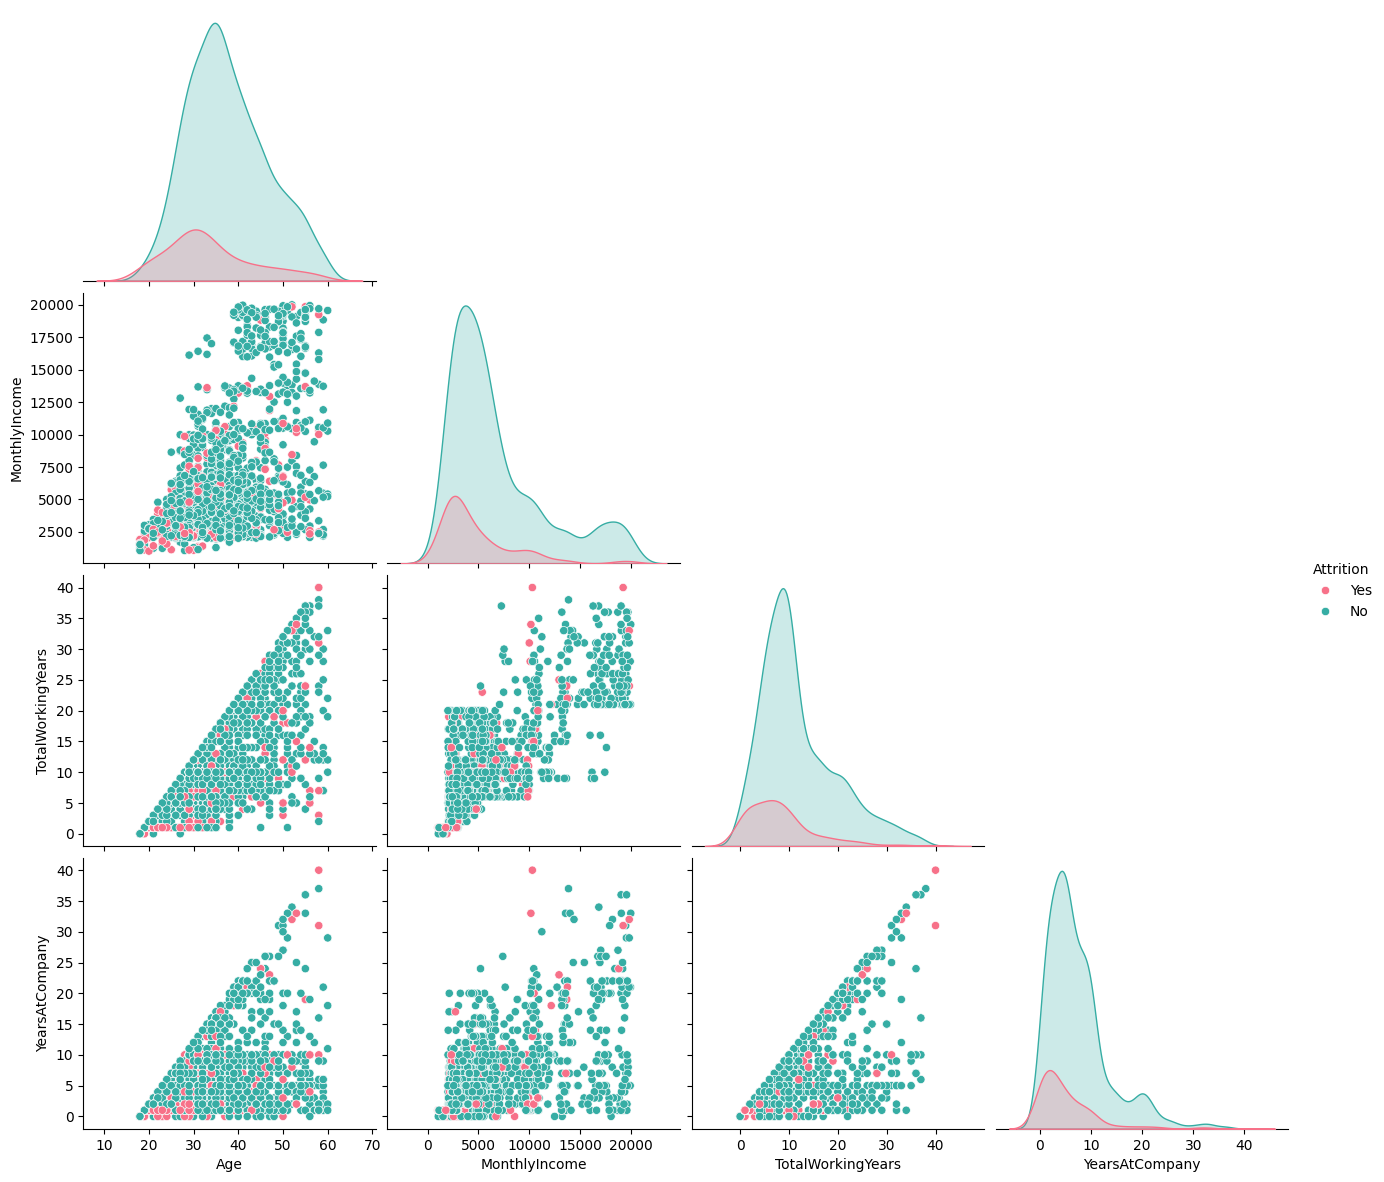

In [3]:
# ==========================================
# 4. Exploratory Data Analysis (EDA) - UPGRADE
# ==========================================

print("=== 1. INFORMASI RINGKAS DATASET ===")
df.info()
print("\n")


print("=== 2. STATISTIK DESKRIPTIF TOTAL ===")
# Menggunakan include='all' seperti temanmu agar memuat numerik dan kategorikal sekaligus
display(df.describe(include='all'))
print("\n")


print("=== 3. PENGECEKAN MISSING VALUES & DUPLIKAT ===")
missing_values = df.isnull().sum()
print("[Missing Values per Kolom]")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "Tidak ada missing values di kolom mana pun.")
print(f"\nJumlah total baris duplikat: {df.duplicated().sum()}")
print("\n")


print("=== 4. DETEKSI FITUR KONSTAN ===")
# Fitur dengan 1 nilai unik tidak berguna untuk ML, penting dicatat untuk preprocessing
constant_features = [col for col in df.columns if df[col].nunique() == 1]
print(f"Fitur konstan/redundant yang terdeteksi: {constant_features}")
print("\n")


print("=== 5. VISUALISASI DISTRIBUSI & HUBUNGAN VARIABEL (UNIVARIAT & BIVARIAT) ===")
# Visualisasi 1: Distribusi Target (Attrition)
plt.figure(figsize=(7, 4))
sns.countplot(x='Attrition', data=df, palette='Set2')
plt.title('Distribusi Variabel Target (Attrition)')
plt.xlabel('Karyawan Keluar? (Attrition)')
plt.ylabel('Frekuensi / Jumlah')
plt.show()

# Visualisasi 2: Hubungan Kerja Lembur (OverTime) dengan Attrition
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='OverTime', hue='Attrition', palette='viridis')
plt.title('Distribusi Attrition Berdasarkan Kebiasaan Lembur (OverTime)')
plt.xlabel('Kerja Lembur?')
plt.ylabel('Jumlah Karyawan')
plt.show()


print("=== 6. DETEKSI OUTLIER (BOXPLOT) ===")
# Membuat Boxplot untuk fitur numerik utama untuk melihat pencilan data ekstrem
plt.figure(figsize=(10, 5))
numeric_features_for_box = ['Age', 'DistanceFromHome', 'TotalWorkingYears', 'YearsAtCompany']
sns.boxplot(data=df[numeric_features_for_box], palette='Set3')
plt.title('Deteksi Outlier pada Fitur Numerik Utama IBM HR')
plt.ylabel('Nilai')
plt.show()


print("=== 7. ANALISIS KORELASI (HEATMAP) ===")
# Memilih kolom bertipe numerik saja secara otomatis dari dataset asli
plt.figure(figsize=(12, 9))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
# Mengambil sampel beberapa kolom numerik terpenting agar heatmap terbaca jelas
cols_to_corr = ['Age', 'DailyRate', 'DistanceFromHome', 'MonthlyIncome',
                'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole']
korelasi = numeric_df[cols_to_corr].corr()
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur Numerik Pilihan')
plt.show()


print("=== 8. DISTRIBUSI MULTIVARIAT (PAIRPLOT) ===")
# Mengambil sebagian fitur numerik utama untuk pairplot agar visualisasi lega dan tidak crash
cols_for_pairplot = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'Attrition']
sns.pairplot(df[cols_for_pairplot].dropna(), hue='Attrition', palette='husl', corner=True, height=3.0, aspect=1.1)
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# ==========================================
# 5. Data Preprocessing
# ==========================================

# Catatan MLOps: Sebelum masuk ke pipeline, kita lakukan pembersihan struktural dasar
# pada dataframe (Drop kolom tidak relevan, Duplikat, dan Target Encoding).

# Eliminasi fitur yang konstan/identifier unik dari EDA awal
columns_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df_clean = df.drop(columns=columns_to_drop, errors='ignore').copy()


print("=== 1. MENGHAPUS ATAU MENANGANI DATA KOSONG (MISSING VALUES) ===")
# Catatan: Karena kita menggunakan scikit-learn Pipeline untuk skalabilitas produksi,
# penanganan missing values pada FITUR (X) akan didelegasikan ke `SimpleImputer` di langkah ke-3.
# Di sini, kita memastikan tidak ada missing values pada variabel TARGET ('Attrition').
if df_clean['Attrition'].isnull().sum() > 0:
    df_clean = df_clean.dropna(subset=['Attrition'])
    print("• Baris dengan nilai target kosong berhasil dihapus.")
else:
    print("• Tidak ditemukan nilai kosong pada variabel target.")


print("\n=== 2. MENGHAPUS DATA DUPLIKAT ===")
# Menghapus duplikasi baris data untuk menghindari bias saat pembagian data train-test
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
dropped_duplicates = initial_rows - len(df_clean)
print(f"• Selesai mengecek duplikasi. Menghapus {dropped_duplicates} baris data duplikat.")


print("\n=== 3. NORMALISASI ATAU STANDARISASI FITUR ===")
# Mengubah target Attrition dari bentuk teks ('Yes'/'No') menjadi biner (1/0)
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})

# Memisahkan Fitur (X) dan Target (y)
X = df_clean.drop(columns=['Attrition'])
y = df_clean['Attrition']

# Otomatisasi pemisahan nama kolom berdasarkan tipe data untuk pipeline
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# MLOps Best Practice: Konfigurasi Pipeline Standarisasi untuk fitur numerik
# Imputasi dilakukan di sini (menangani poin 1) dan dilanjutkan dengan Standarisasi (Z-score scaller)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
print("• Pipeline konfigurasi Standarisasi (StandardScaler) untuk fitur numerik siap.")


print("\n=== 4. DETEKSI DAN PENANGANAN OUTLIER ===")
# Membatasi nilai ekstrem pada kolom numerik utama menggunakan batas IQR Capping (Winsorizing)
outlier_cols = ['TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole']

for col in outlier_cols:
    if col in X.columns:
        Q1 = X[col].quantile(0.25)
        Q3 = X[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Capping nilai ekstrem ke batas atas dan batas bawah langsung pada matriks X
        X[col] = np.where(X[col] > upper_bound, upper_bound, X[col])
        X[col] = np.where(X[col] < lower_bound, lower_bound, X[col])
print("• Deteksi selesai: Nilai outlier pada fitur utama berhasil dibatasi dengan metode IQR Capping.")


print("\n=== 5. ENCODING DATA KATEGORIKAL ===")
# MLOps Best Practice: Menggunakan OneHotEncoder di dalam pipeline untuk menangani data baru di produksi
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Menggabungkan seluruh transformasi (Poin 3 & Poin 5) ke dalam ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)
print("• Skema One-Hot Encoding untuk fitur kategorikal berhasil diintegrasikan ke pipeline.")


print("\n=== 6. BINNING (PENGELOMPOKAN DATA) ===")
# Menerapkan teknik Binning: Pengelompokan umur karyawan menjadi 3 kategori logis sebelum dieksekusi
X['Age_Group'] = pd.cut(X['Age'], bins=[0, 30, 45, 100], labels=['Young', 'Middle-Aged', 'Senior'])

# [Opsional/Tambahan] Feature engineering pendukung: Rasio masa kerja
X['Company_Working_Ratio'] = X['YearsAtCompany'] / (X['TotalWorkingYears'] + 1)

# Perbarui daftar fitur kategorikal karena ada 'Age_Group' baru hasil binning
if 'Age_Group' not in categorical_features:
    categorical_features.append('Age_Group')
print("• Fitur baru 'Age_Group' (Hasil Binning) berhasil dikonstruksi.")


# ==========================================
# EKSEKUSI PIPELINE & DATA SPLITTING (MLOps Deployment Ready)
# ==========================================
print("\n=== PROSES AKHIR: SPLITTING & TRANSFORMASI PIPELINE ===")
# Membagi data menjadi 80% Latih dan 20% Uji dengan stratifikasi kelas target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Eksekusi pipeline (Mencegah Data Leakage!)
X_train_clean = preprocessor.fit_transform(X_train)
X_test_clean = preprocessor.transform(X_test)

# Rekonstruksi DataFrame untuk penyimpanan lokal
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
encoded_cat_cols = cat_encoder.get_feature_names_out(categorical_features).tolist()
final_columns = numeric_features + encoded_cat_cols

df_train_final = pd.DataFrame(X_train_clean, columns=final_columns)
df_train_final['Attrition'] = y_train.values

# Ekspor data bersih
clean_file_name = "ibm_attrition_preprocessing.csv"
df_train_final.to_csv(clean_file_name, index=False)
print(f"✓ Berkas hasil preprocessing sukses diekspor: {clean_file_name}\n")

print("=== TABEL DATA SETELAH PREPROCESSING (5 BARIS PERTAMA) ===")
display(df_train_final.head())
print(f"\nTotal Missing Values Tersisa pada Data Bersih: {df_train_final.isnull().sum().sum()}")

=== 1. MENGHAPUS ATAU MENANGANI DATA KOSONG (MISSING VALUES) ===
• Tidak ditemukan nilai kosong pada variabel target.

=== 2. MENGHAPUS DATA DUPLIKAT ===
• Selesai mengecek duplikasi. Menghapus 0 baris data duplikat.

=== 3. NORMALISASI ATAU STANDARISASI FITUR ===
• Pipeline konfigurasi Standarisasi (StandardScaler) untuk fitur numerik siap.

=== 4. DETEKSI DAN PENANGANAN OUTLIER ===
• Deteksi selesai: Nilai outlier pada fitur utama berhasil dibatasi dengan metode IQR Capping.

=== 5. ENCODING DATA KATEGORIKAL ===
• Skema One-Hot Encoding untuk fitur kategorikal berhasil diintegrasikan ke pipeline.

=== 6. BINNING (PENGELOMPOKAN DATA) ===
• Fitur baru 'Age_Group' (Hasil Binning) berhasil dikonstruksi.

=== PROSES AKHIR: SPLITTING & TRANSFORMASI PIPELINE ===
✓ Berkas hasil preprocessing sukses diekspor: ibm_attrition_preprocessing.csv

=== TABEL DATA SETELAH PREPROCESSING (5 BARIS PERTAMA) ===


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes,Age_Group_Middle-Aged,Age_Group_Senior,Age_Group_Young,Attrition
0,1.090194,1.049455,-0.899915,1.064209,-0.658710,-0.908436,1.795282,1.762189,-0.647997,2.026752,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
1,-1.634828,-0.523449,-0.899915,-1.855332,0.260202,1.694111,0.373564,-0.986265,1.153526,-0.864408,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0
2,0.981193,-0.992080,-0.777610,-1.855332,-1.577622,-0.662913,0.373564,1.762189,0.252765,2.347706,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0
3,-1.307825,-0.453653,0.445433,-1.855332,-0.658710,-1.252169,0.373564,-0.986265,0.252765,-0.956202,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0
4,0.654191,0.491086,-0.043784,2.037390,1.179114,0.319180,0.373564,-0.070114,0.252765,-0.185956,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0



Total Missing Values Tersisa pada Data Bersih: 0
